# Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Load Dataset

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()  # Lihat 5 baris pertama
df.info()  # Lihat info dataset
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31571 entries, 0 to 31570
Data columns (total 7 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   Year                                                              31571 non-null  int64 
 1   Economy                                                           31571 non-null  int64 
 2   Economy Label                                                     31571 non-null  object
 3   Absolute value in thousands                                       31571 non-null  object
 4   Absolute value in thousands Missing value                         31571 non-null  object
 5   Urban population as percentage of total population                31571 non-null  object
 6   Urban population as percentage of total population Missing value  31571 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.7+

In [ ]:
print(df[["Economy", "Economy Label"]].head(10))

   Economy         Economy Label
0        1  Individual economies
1        4           Afghanistan
2        8               Albania
3       12               Algeria
4       16        American Samoa
5       20               Andorra
6       24                Angola
7      660              Anguilla
8       28   Antigua and Barbuda
9       32             Argentina


# Menampilkan Daftar Negara dan Entitas

In [ ]:
countries_entities = df["Economy Label"].unique()
print("Total negara/entitas:", len(countries_entities))
print("Contoh negara/entitas:", countries_entities[:10])

Total negara/entitas: 313
Contoh negara/entitas: ['Individual economies' 'Afghanistan' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina']


# Menampilkan daftar ekonomi (negara/entitas)

In [7]:
print("Daftar Ekonomi dalam Dataset:")
print(df['Economy'].unique())

Daftar Ekonomi dalam Dataset:
[   1    4    8   12   16   20   24  660   28   32   51  533   36   40
   31   44   48   50   52  112   56   84  204   60   64   68  535   70
   72   76   92   96  100  854  108  132  116  120  124  136  140  148
  152  156  344  446  158  170  174  178  180  184  188  384  191  192
  531  196  203  200  208  262  212  214  218  818  222  226  232  233
  748  231  230  238  234  242  246  251  250  254  312  474  175  492
  638  258  266  270  268  276  280  288  292  300  304  308  316  320
  324  624  328  332  336  340  348  352  356  360  960  364  368  372
  376  380  388  392  400  398  404  296  408  410  414  417  418  428
  422  426  430  434  440  442  450  454  458  462  466  470  584  478
  480  484  583  498  496  499  500  504  508  104  516  520  524  528
  530  540  554  558  562  566  570  807  580  579  512  582  586  585
  591  590  598  600  604  608  616  620  634  642  643  646  652  654
  659  662  663  666  670  882  674  678  682  

# Data Cleaning dan Pemrosesan

## Mengonversi kolom populasi dan presentase populasi urban ke numerik:

In [8]:
df["Absolute value in thousands"] = pd.to_numeric(df["Absolute value in thousands"], errors="coerce")
df["Urban population as percentage of total population"] = pd.to_numeric(
    df["Urban population as percentage of total population"], errors="coerce")

df.dropna(subset=["Absolute value in thousands", "Urban population as percentage of total population"], inplace=True)

## Mengonversi nama negara menjadi angka (Label Encoding):

In [9]:
label_encoder = LabelEncoder()
df["Economy Label Encoded"] = label_encoder.fit_transform(df["Economy Label"])

# Menyiapkan Data untuk Prediksi

## Menentukan Variable Fitur (x) dan Target (y)


In [10]:
X = df[["Year", "Urban population as percentage of total population", "Economy Label Encoded"]]
y = df["Absolute value in thousands"]

## Membagi data menjadi train dan test set

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menerapkan Regresi Linear

## Melatih model regresi linier:

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Prediksi populasi dalam 1 tahun ke depan:

In [13]:
next_year = df["Year"].max() + 1
X_pred = df[["Urban population as percentage of total population", "Economy Label Encoded"]].copy()
X_pred.insert(0, "Year", next_year)

y_pred = model.predict(X_pred)

## Membuat DataFrame hasil prediksi:

In [ ]:
predictions = pd.DataFrame({"Economy Label": df["Economy Label"], "Predicted Population": y_pred})
print(predictions.head(10))

          Economy Label  Predicted Population
1           Afghanistan         881834.325847
2               Albania         821989.358038
3               Algeria         814131.936099
4        American Samoa         656492.971826
5               Andorra         744954.962846
6                Angola         867255.095133
7              Anguilla         500514.272984
8   Antigua and Barbuda         775922.352967
9             Argentina         635218.574654
11                Aruba         689832.342367


# Visualisasi Hasil Prediksi

## Filter Dataset Berdasarkan Negara yang Dipilih

In [ ]:
# Pilih nama negara yang ingin dianalisis
selected_country = "Indonesia"

# Filter dataset berdasarkan negara yang dipilih
df_country = df[df["Economy Label"] == selected_country]

## Membersihkan Data sebelum Digunakan dalam Model

In [25]:
import numpy as np

# Ubah "NOT APPLICABLE" menjadi NaN
df_country.replace("NOT APPLICABLE", np.nan, inplace=True)

# Hapus baris yang memiliki nilai NaN
df_country.dropna(subset=["Absolute value in thousands"], inplace=True)

# Konversi kolom ke numerik
df_country["Absolute value in thousands"] = df_country["Absolute value in thousands"].astype(float)

C:\Users\rezaa\AppData\Local\Temp\ipykernel_30184\992440506.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country.replace("NOT APPLICABLE", np.nan, inplace=True)
C:\Users\rezaa\AppData\Local\Temp\ipykernel_30184\992440506.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country.dropna(subset=["Absolute value in thousands"], inplace=True)
C:\Users\rezaa\AppData\Local\Temp\ipykernel_30184\992440506.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

## Mengkonversi tipe data kolom "Year" menjadi int

In [26]:
df_country["Year"] = df_country["Year"].astype(int)

C:\Users\rezaa\AppData\Local\Temp\ipykernel_30184\3802084904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country["Year"] = df_country["Year"].astype(int)


## Memeriksa apakah X_train dan X_test cocok

In [ ]:
print("Fitur dalam X_train:", X_train.columns.tolist())
print("Fitur dalam X_test:", X_test.columns.tolist())

Fitur dalam X_train: ['Year', 'Urban population as percentage of total population', 'Economy Label Encoded']
Fitur dalam X_test: ['Year', 'Urban population as percentage of total population', 'Economy Label Encoded']


## Memastikan bahwa fitur yang digunakan dalam X_test sesuai dengan fitur yang digunakan saat training pada X_train

In [ ]:
# Gunakan fitur yang sama seperti saat training
X_test = X_test[["Year"]]

## Visualisasi

d:\python\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


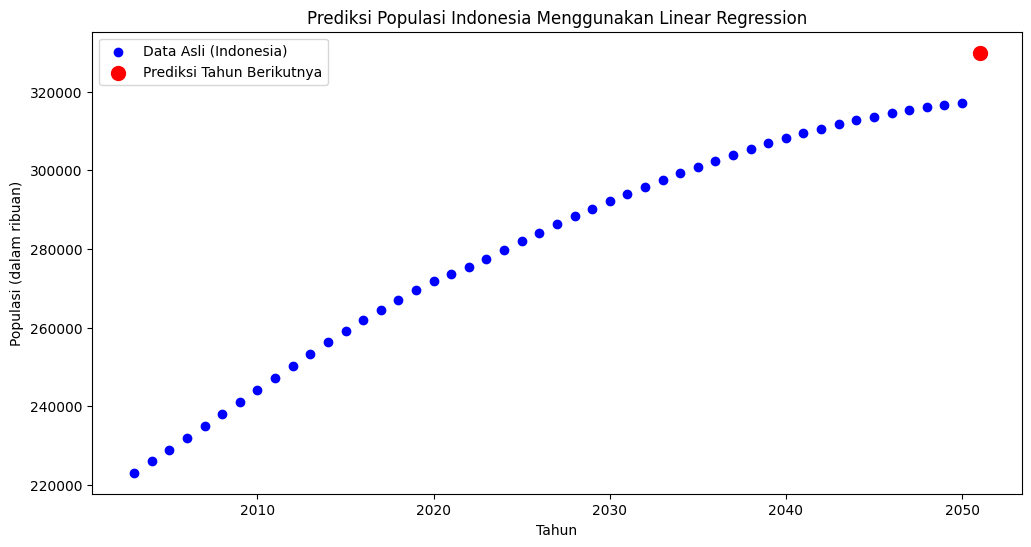

In [31]:
# Buat variabel X (tahun) dan y (populasi)
X_country = df_country[["Year"]]  # Pastikan X dalam bentuk DataFrame
y_country = df_country["Absolute value in thousands"]

# Buat model regresi linier
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_country, y_country)

# Prediksi populasi tahun berikutnya
next_year = df_country["Year"].max() + 1
y_pred = model.predict([[next_year]])

# Visualisasi data asli dan prediksi
plt.figure(figsize=(12, 6))

# Plot populasi asli untuk negara yang dipilih
plt.scatter(df_country["Year"], df_country["Absolute value in thousands"], color="blue", label=f"Data Asli ({selected_country})")

# Plot prediksi populasi tahun berikutnya
plt.scatter(next_year, y_pred, color="red", label="Prediksi Tahun Berikutnya", s=100)

plt.xlabel("Tahun")
plt.ylabel("Populasi (dalam ribuan)")
plt.title(f"Prediksi Populasi {selected_country} Menggunakan Linear Regression")
plt.legend()
plt.show()

# Evaluasi Akurasi Model (ga kepake ini)

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

y_test_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")


Mean Absolute Error: 400992.9723419675
R² Score: 0.004663012610557016


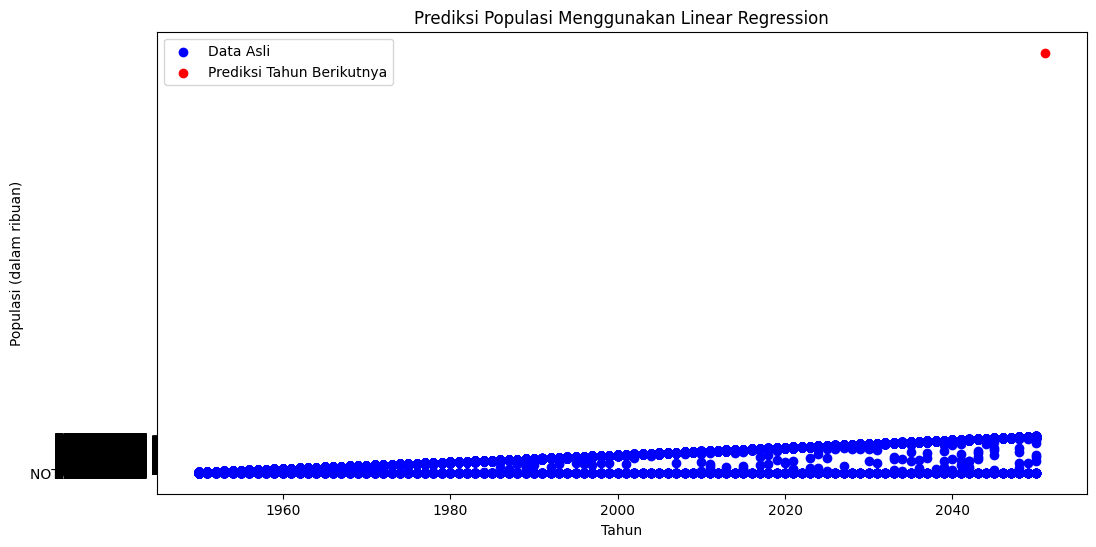

In [33]:
plt.figure(figsize=(12, 6))

# Plot populasi asli
plt.scatter(df["Year"], df["Absolute value in thousands"], color="blue", label="Data Asli")

# Plot populasi yang diprediksi
plt.scatter([next_year] * len(y_pred), y_pred, color="red", label="Prediksi Tahun Berikutnya")

plt.xlabel("Tahun")
plt.ylabel("Populasi (dalam ribuan)")
plt.title("Prediksi Populasi Menggunakan Linear Regression")
plt.legend()
plt.show()
